# **Air Quality Monitor Representativeness in the Contiguous United States**

#### **Objective:** Determine whether state and local governments site air monitors in areas that capture data that are representative of actual air quality. For this analysis, assign county identifers to each monitor to ease future comparisons to the county median alternative PM2.5 dataset.

#### **Scope:** U.S. PM2.5 air quality monitors in the contiguous U.S. in 2019.

#### **Sources:**

| Num. | Title | Description | Source Link |
| :--- | :------------------------------ | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1. | _daily_88101_2019_processed_v02.csv_ | This processed dataset contains each PM2.5 monitor location and their alternative PM2.5 estimates for every day in the year 2019 within the contiguous United States. | NA <br><br> (Developed by this project in B_air_monitors_w_alt_data_extraction)
| 2 | tl\_2019\_us\_county.zip | Derived from the U.S. Census Bureau on 11/30/2025, this dataset contains each of the U.S. county boundaries in shapefile format. | Data: <br>[https://www.census.gov/cgi\-bin/geo/shapefiles/index.php](https://www.census.gov/cgi-bin/geo/shapefiles/index.php) |


#### **Conclusions:** Each monitor was assigned the unique identifier for its county in the exported dataset alternative_PM25_data_w_county_ID_processed_v04. This dataset will allow me to combine the air quality monitors to the county median dataset for final analysis.

#### General Methodology

##### Steps

1. Load Libraries
2. Load Processed Air Quality Monitor Dataset
3. Load Processed Contiguous Counties Dataset
4. Extract County Identifiers into the Processed Air Quality Monitor Dataset


#### Load Libraries

In [3]:
#Purpose of Cell Block: Load libraries I will likely need
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(tidyr))
suppressPackageStartupMessages(library(readr))
suppressPackageStartupMessages(library(vroom))
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(stringr))
suppressPackageStartupMessages(library(terra))
suppressPackageStartupMessages(library(naniar))
suppressPackageStartupMessages(library(tidyterra))
suppressPackageStartupMessages(library(exactextractr))
suppressPackageStartupMessages(library(sf))
suppressPackageStartupMessages(library(lubridate))

if (!require(dplyr)) install.packages("dplyr")
if (!require(dplyr)) install.packages("tidyr")
if (!require(readr)) install.packages("readr")
if (!require(vroom)) install.packages("vroom")
if (!require(ggplot2)) install.packages("ggplot2")
if (!require(stringr)) install.packages("stringr")
if (!require(terra)) install.packages("terra")
if (!require(naniar)) install.packages("naniar")
if (!require(tidyterra)) install.packages("tidyterra")
if (!require(exactextractr)) install.packages("exactextractr")
if (!require(sf)) install.packages("sf")
if (!require(sf)) install.packages("lubridate")

library(dplyr)
library(tidyr)
library(readr)
library(vroom)
library(ggplot2)
library(stringr)
library(terra)
library(naniar)
library(tidyterra)
library(exactextractr)
library(sf)
library(lubridate)

# Note: exactextractr is an R package that quickly and accurately summarizes raster values over polygonal areas, commonly referred to as zonal statistics. Unlike most zonal statistics implementations, it handles grid cells that are partially covered by a polygon. Despite this, it performs faster other packages for many real-world applications.
# https://cran.r-project.org/web/packages/exactextractr/readme/README.html


#### Load Processed Air Quality Monitor Dataset

In [4]:
#Purpose of Cell Block: Load Processed AQM+AltPM25 Dataset 
setwd("/home/user/capstone/A_data")
DF_altpm25_processed <- read.csv("D_processed_data/alternative_PM25_data/alternative_PM25_data_processed_v02.csv") %>%
    mutate('AQS_Site_ID' = str_pad(AQS_Site_ID, width = 9, pad = 0)) %>% #pad leading zero so state code always 9 char
    mutate(Date = as.Date(Date)) #converting date value from character to date

head(DF_altpm25_processed)

,AQS_Site_ID,Latitude,Longitude,Address,State,County,City,Date,PM25_ugm3,Alt_PM25
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<date>,<dbl>,<dbl>
1,010030010,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,2019-01-01,NA,7.2
2,010270001,33.28493,-85.80361,ASHLAND AIRPORT,Alabama,Clay,Ashland,2019-01-01,NA,6.0
3,010331002,34.76262,-87.63810,WILSON DAM RD AND 2ND ST.,Alabama,Colbert,Muscle Shoals,2019-01-01,NA,5.0
4,010491003,34.28857,-85.96986,"13112 HWY.68 , CROSSVILLE AL. 35962",Alabama,DeKalb,Crossville,2019-01-01,NA,6.2
5,010550010,33.98821,-85.99256,"314 COLLEGE DRIVE, GADSDEN, AL 35902",Alabama,Etowah,Gadsden,2019-01-01,NA,7.9
6,010690003,31.22478,-85.39079,126 NORTH ST. ANDREWS STREET (CIVIC CENTER),Alabama,Houston,Dothan,2019-01-01,NA,10.4


#### Load Processed Contiguous Counties Dataset


Reading layer `contiguous_counties' from data source 
  `/home/user/capstone/A_data/D_processed_data/intermediate_scratch/contiguous_counties.gpkg' 
  using driver `GPKG'
Simple feature collection with 3108 features and 17 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -124.849 ymin: 24.39631 xmax: -66.88544 ymax: 49.38448
Geodetic CRS:  NAD83


Registered S3 method overwritten by 'geojsonsf':
  method        from   
  print.geojson geojson



,FIPS_Fix,COUNTYFP,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geom
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<MULTIPOLYGON [°]>
1,31,039,00835841,31039,Cuming,Cuming County,06,H1,G4020,NA,NA,NA,A,1477652222,10690952,+41.9158651,-096.7885168,MULTIPOLYGON (((-97.01952 4...
2,53,069,01513275,53069,Wahkiakum,Wahkiakum County,06,H1,G4020,NA,NA,NA,A,680962890,61582307,+46.2946377,-123.4244583,MULTIPOLYGON (((-123.4364 4...
3,35,011,00933054,35011,De Baca,De Baca County,06,H1,G4020,NA,NA,NA,A,6016819475,29089486,+34.3592729,-104.3686961,MULTIPOLYGON (((-104.5674 3...
4,31,109,00835876,31109,Lancaster,Lancaster County,06,H1,G4020,339,30700,NA,A,2169270569,22849484,+40.7835474,-096.6886584,MULTIPOLYGON (((-96.91075 4...
5,31,129,00835886,31129,Nuckolls,Nuckolls County,06,H1,G4020,NA,NA,NA,A,1489645188,1718484,+40.1764918,-098.0468422,MULTIPOLYGON (((-98.27367 4...
6,46,099,01265772,46099,Minnehaha,Minnehaha County,06,H1,G4020,NA,43620,NA,A,2089691755,18198481,+43.6674723,-096.7957261,MULTIPOLYGON (((-97.12928 4...


The number of unique values in the COUNTYNS is (i.e., use this column as a unique identifier for counties): 3108 


The number of unique lengths of values in the COUNTYNS is: 1 


The number I need to pad COUNTYNS when I import the CSV is: 8

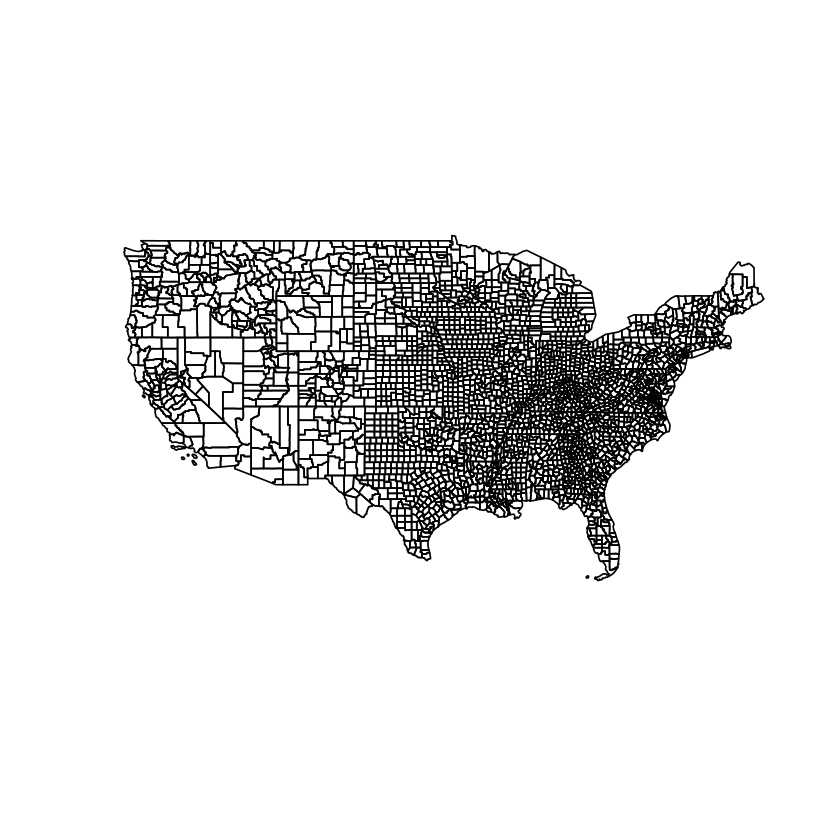

In [5]:
#Purpose of Cell Block: Load contiguous counties
setwd("/home/user/capstone/A_data")
contiguous_counties <- st_read("D_processed_data/intermediate_scratch/contiguous_counties.gpkg") 

plot(st_geometry(contiguous_counties))

head(contiguous_counties)

cat(
    "The number of unique values in the COUNTYNS is (i.e., use this column as a unique identifier for counties):",
    n_distinct(contiguous_counties$COUNTYNS), "\n" #This is the variable I'll need to keep for each county to merge my output back once I'm done processing it's a unique identifier
)

#The following code confirms the length of the unique identifier code b/c the padded zeros are lost when I convert the dataset to csv
countiguous_counties_len <- contiguous_counties %>% #create new column called "len" and count the number of characters in in COUNTYNS
    st_drop_geometry() %>% #drop geometry, given not needed for this analysis
    mutate(len = nchar(COUNTYNS))

#show whether any the values in the identfier variable change
cat(
    "The number of unique lengths of values in the COUNTYNS is:",
    n_distinct(countiguous_counties_len$len), "\n" #confirm all values are the same length
)

#show the pad number
cat(
    "The number I need to pad COUNTYNS when I import the CSV is:",
    head(countiguous_counties_len$len, 1)
)


#### Extract County Identifiers into the Processed Air Quality Monitor Dataset

In [6]:
#Purpose of Cell Block: Convert datasets to sf and align crs to ensure matching, then assign the county's unique identifier to the monitors

monitors_sf <- DF_altpm25_processed %>% #convert monitors to SF with lat/long
    st_as_sf(
        coords = c("Longitude", "Latitude"),
        crs = 4326,# WGS84
        remove = FALSE
    )

counties_sf <- contiguous_counties %>% #convert countises to sf
    st_as_sf()


counties_sf <- st_transform(counties_sf, st_crs(monitors_sf)) #align crs

monitors_with_county <- monitors_sf %>%
    st_join(counties_sf %>% #join monitors within (see rule below) counties
        select(COUNTYNS), #grab the countyns valuefor new column
        join = st_within,
        left = TRUE
  )


head(monitors_with_county)

,AQS_Site_ID,Latitude,Longitude,Address,State,County,City,Date,PM25_ugm3,Alt_PM25,COUNTYNS,geometry
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<date>,<dbl>,<dbl>,<chr>,<POINT [°]>
1,010030010,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,2019-01-01,NA,7.2,00161527,POINT (-87.88026 30.49748)
2,010270001,33.28493,-85.80361,ASHLAND AIRPORT,Alabama,Clay,Ashland,2019-01-01,NA,6.0,00161539,POINT (-85.80361 33.28493)
3,010331002,34.76262,-87.63810,WILSON DAM RD AND 2ND ST.,Alabama,Colbert,Muscle Shoals,2019-01-01,NA,5.0,00161542,POINT (-87.6381 34.76262)
4,010491003,34.28857,-85.96986,"13112 HWY.68 , CROSSVILLE AL. 35962",Alabama,DeKalb,Crossville,2019-01-01,NA,6.2,00161550,POINT (-85.96986 34.28857)
5,010550010,33.98821,-85.99256,"314 COLLEGE DRIVE, GADSDEN, AL 35902",Alabama,Etowah,Gadsden,2019-01-01,NA,7.9,00161553,POINT (-85.99256 33.98821)
6,010690003,31.22478,-85.39079,126 NORTH ST. ANDREWS STREET (CIVIC CENTER),Alabama,Houston,Dothan,2019-01-01,NA,10.4,00161560,POINT (-85.39079 31.22478)


In [3]:
#Purpose of Cell Block: Export the final dataset as a csv (i.e., no geometry needed)

monitors_final <- monitors_with_county %>%
    st_drop_geometry()


final_output_path <- "D_processed_data/alternative_PM25_data/alternative_PM25_data_w_county_ID_processed_v04.csv"
write_csv(monitors_final, final_output_path)

#Conclusion: The dataset was successfully exported and I am now ready to conduct my final analysis

ERROR: Error in monitors_with_county %>% st_drop_geometry(): could not find function "%>%"
